# Week 6 - Day 3: Backpropagation, Gradient Descent & Optimizers

Day 2 ended at the loss: the network makes a prediction, then the loss tells us how wrong that prediction is.

Today I continue from that point and focus on how the network actually learns from the error. The main training cycle is:

**forward pass → loss → backpropagation → parameter update**

The practical experiment at the end uses a very small NumPy network so I can isolate the effect of the learning rate without introducing the full Keras workflow before Day 4.

## 1. The training loop

A training step has four main parts:

1. **Forward pass** — compute the prediction using the current weights and biases.
2. **Loss** — compare the prediction with the true value and measure the error.
3. **Backpropagation** — work backward from the loss and compute how sensitive the loss is to each parameter.
4. **Update** — use an optimizer to change the parameters in a direction that should reduce the loss.

After the update, the next forward pass uses the new parameters. Repeating this process is what turns the initial random parameters into useful ones.

## 2. Gradient descent and the learning rate

For one parameter $w$, the basic gradient-descent update is:

$$
w_{new} = w_{old} - \eta \frac{\partial L}{\partial w}
$$

where:

- $L$ is the loss;
- $\frac{\partial L}{\partial w}$ is the gradient for that parameter;
- $\eta$ is the learning rate.

The gradient points toward the direction of steepest increase in the loss, so gradient descent moves in the opposite direction.

The learning rate controls the size of each update. If it is too small, training improves very slowly. If it is too large, the updates can overshoot good regions and the loss may oscillate or diverge. A useful learning rate gives a steady decrease in the loss.

## 3. Backpropagation

Backpropagation is the procedure used to compute the gradients efficiently through the network.

A parameter in an early layer does not affect the final loss directly. Its effect passes through the later operations first. The chain rule connects those effects. For a simple path such as

$$
w \rightarrow z \rightarrow a \rightarrow L
$$

the derivative is built as

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial a}
\frac{\partial a}{\partial z}
\frac{\partial z}{\partial w}
$$

So the backward pass starts from the loss and moves toward the earlier layers, calculating the contribution of each parameter to the error.

The important distinction is:

- **backpropagation computes the gradients**;
- **the optimizer uses those gradients to update the parameters**.

## 4. Optimizers, epochs, and batches

| Term | Meaning |
|---|---|
| **SGD** | Applies gradient-based updates directly using a learning rate. |
| **Adam** | Adapts the update size for individual parameters using running statistics of the gradients. |
| **Epoch** | One complete pass through the training dataset. |
| **Batch** | A subset of the training data used before one parameter update. |

If a training set has 1,000 samples and the batch size is 100, there are 10 parameter updates in one epoch.

Adam is commonly used as a default optimizer in neural-network training, while SGD is useful for understanding the basic update rule clearly.

## 5. Learning-rate experiment

I will use the same tiny network, the same initial parameters, and the same data for all runs. The only value that changes is the learning rate.

The network is deliberately small:

**1 input → 8 hidden tanh units → 1 output**

The task is a small synthetic regression problem. I am not using the Heart Disease dataset here because the purpose of this experiment is only to observe training behavior. The project network itself belongs to the Keras training work on Day 4.

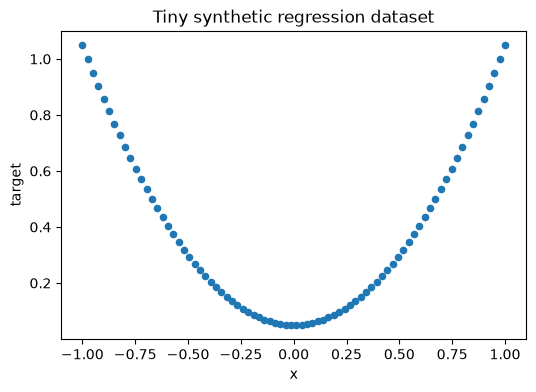

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42

X = np.linspace(-1.0, 1.0, 80).reshape(-1, 1)
y = X**2 + 0.05

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], y[:, 0], s=20)
plt.xlabel("x")
plt.ylabel("target")
plt.title("Tiny synthetic regression dataset")
plt.show()

### Network and training functions

The code below keeps the forward pass, backward pass, and gradient-descent update separate. This makes the four-step training loop visible in code while keeping the experiment small enough to run quickly.

In [2]:
def initialize_parameters(seed=SEED):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, 0.4, size=(1, 8))
    b1 = np.zeros((1, 8))
    W2 = rng.normal(0.0, 0.4, size=(8, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2


def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)
    prediction = a1 @ W2 + b2
    return z1, a1, prediction


def train_network(learning_rate, epochs=300, stop_loss=100.0):
    W1, b1, W2, b2 = initialize_parameters()
    losses = []

    for _ in range(epochs):
        z1, a1, prediction = forward(X, W1, b1, W2, b2)
        error = prediction - y
        loss = np.mean(error**2)
        losses.append(float(loss))

        if not np.isfinite(loss) or loss > stop_loss:
            break

        n = X.shape[0]
        d_prediction = 2.0 * error / n

        dW2 = a1.T @ d_prediction
        db2 = np.sum(d_prediction, axis=0, keepdims=True)

        da1 = d_prediction @ W2.T
        dz1 = da1 * (1.0 - np.tanh(z1)**2)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return np.array(losses)

too low (0.0001)   | epochs run: 300 | final loss: 0.229076
good (0.3)         | epochs run: 300 | final loss: 0.002764
too high (0.7)     | epochs run: 131 | final loss: 218.966406


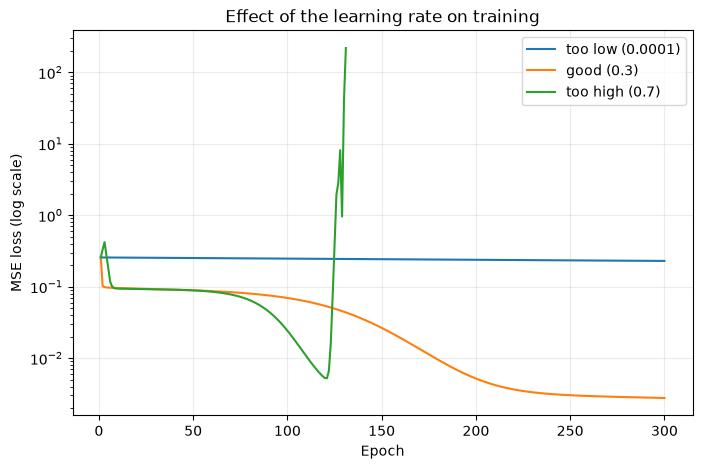

In [3]:
learning_rates = {
    "too low (0.0001)": 0.0001,
    "good (0.3)": 0.3,
    "too high (0.7)": 0.7,
}

results = {
    label: train_network(lr)
    for label, lr in learning_rates.items()
}

for label, losses in results.items():
    print(f"{label:18s} | epochs run: {len(losses):3d} | final loss: {losses[-1]:.6f}")

plt.figure(figsize=(8, 5))
for label, losses in results.items():
    plt.semilogy(range(1, len(losses) + 1), losses, label=label)

plt.xlabel("Epoch")
plt.ylabel("MSE loss (log scale)")
plt.title("Effect of the learning rate on training")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Result

The three runs show the expected learning-rate behavior:

- **0.0001** is too small for this setup. The loss moves in the correct direction but only improves a little after many epochs.
- **0.3** gives a stable decrease and reaches a much lower loss within the same training budget.
- **0.7** is too aggressive. The loss becomes unstable and eventually grows instead of converging.

The comparison uses the same data, architecture, initialization, maximum training budget, and update rule. The high learning-rate run stops early after the loss becomes unstable.
These learning-rate values are specific to this small NumPy experiment. They should not be treated as defaults for Adam or for the Heart Disease model. In the internship material, Adam is introduced with a typical starting learning rate around `0.001`.

## 6. What I take from the experiment

The loss value alone tells me how wrong the network is, but it does not tell the network how to improve. Backpropagation provides the gradients, and the optimizer turns those gradients into parameter updates.

The full training process can therefore be summarized as:

**forward → loss → backward gradients → optimizer update → repeat**

The learning rate matters because it controls how large each update is. Even with the same data and the same network, changing only this value can make training too slow, stable, or unstable.

